Dataset created: (210, 10)
First 5 rows of the dataset:


,product_name,category,price,packaging_type,recyclable,organic,durability,carbon_impact,eco_score,eco_category
0,Plastic Water Bottle,Beverages,19,plastic,no,no,high,high,25,Low
1,Steel Water Bottle,Beverages,194,metal,yes,no,high,high,90,High
2,Paper Bag,Shopping,36,paper,yes,no,medium,high,75,Medium
3,Cloth Bag,Shopping,62,cloth,yes,no,high,high,95,High
4,Plastic Toothbrush,Personal Care,33,plastic,no,no,high,low,20,Low


Dataset Shape: (210, 10)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   product_name    210 non-null    str  
 1   category        210 non-null    str  
 2   price           210 non-null    int64
 3   packaging_type  210 non-null    str  
 4   recyclable      210 non-null    str  
 5   organic         210 non-null    str  
 6   durability      210 non-null    str  
 7   carbon_impact   210 non-null    str  
 8   eco_score       210 non-null    int64
 9   eco_category    210 non-null    str  
dtypes: int64(2), str(8)
memory usage: 16.5 KB

Statistical Summary:


,price,eco_score
count,210.000000,210.000000
mean,178.380952,62.523810
std,204.595055,28.547985
min,1.000000,10.000000
25%,54.000000,35.000000
50%,107.500000,80.000000
75%,216.500000,88.000000
max,928.000000,95.000000



Missing Values:
product_name      0
category          0
price             0
packaging_type    0
recyclable        0
organic           0
durability        0
carbon_impact     0
eco_score         0
eco_category      0
dtype: int64

Eco Category Count:
eco_category
High      90
Low       80
Medium    40
Name: count, dtype: int64


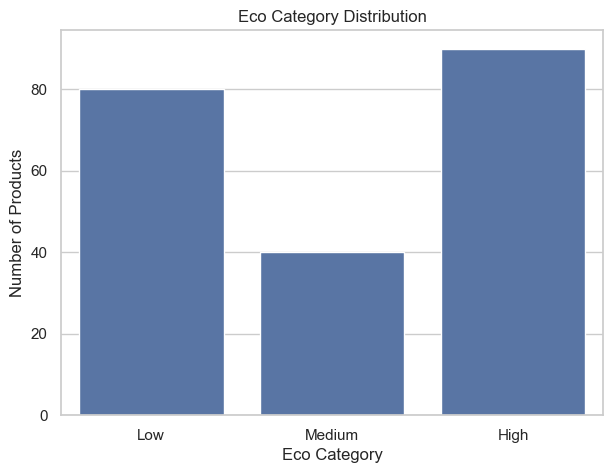


Insight:
This chart shows the distribution of products across Low, Medium, and High eco categories.
It helps us understand whether the dataset is balanced for ML classification.



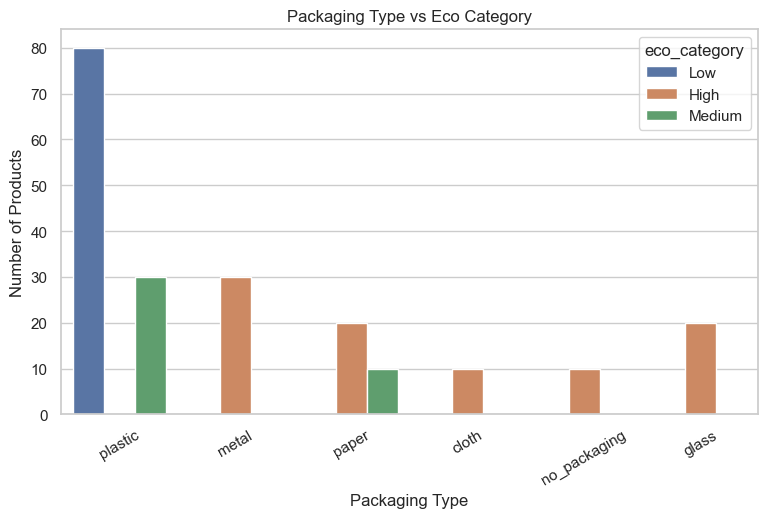


Insight:
Plastic packaging is generally linked with lower sustainability,
while recyclable packaging such as glass, metal, and paper tends to support better eco categories.



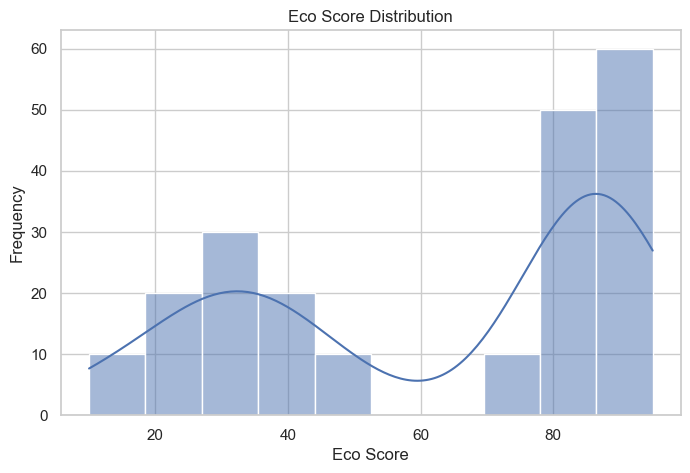


Insight:
The eco score distribution shows how products vary in sustainability.
Higher scores represent more eco-friendly products, while lower scores indicate harmful or less sustainable products.



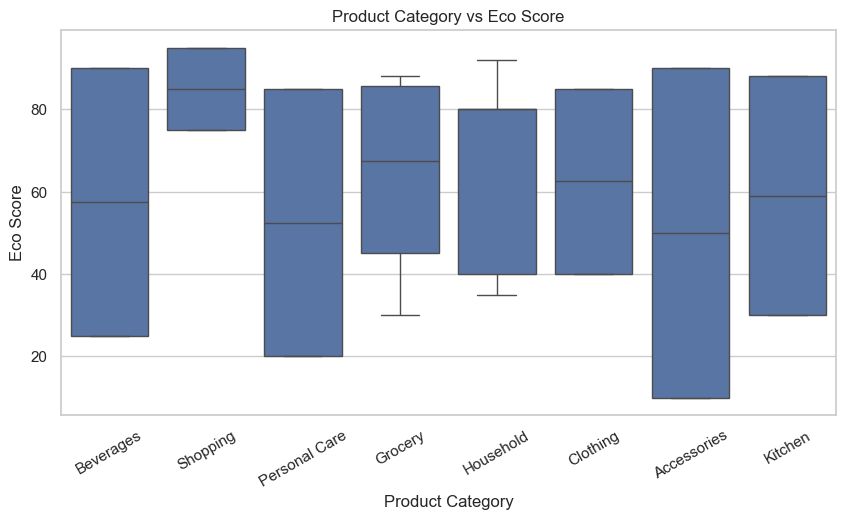


Insight:
This chart helps identify which product categories generally perform better in sustainability.
Some categories may have both low and high eco scores depending on packaging, recyclability, and material type.



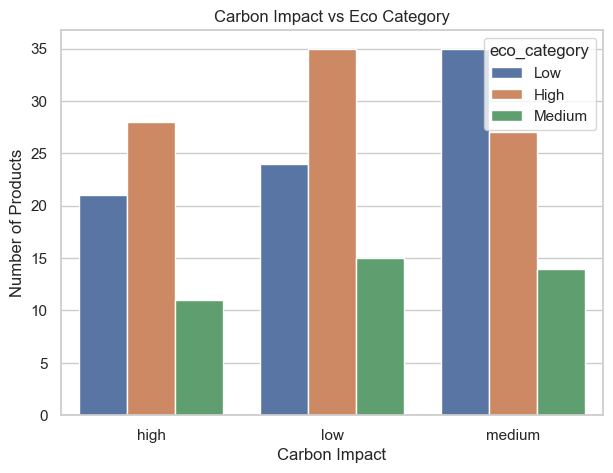


Insight:
Products with high carbon impact mostly fall into the Low eco category,
while low carbon impact products are more likely to be classified as High sustainability products.



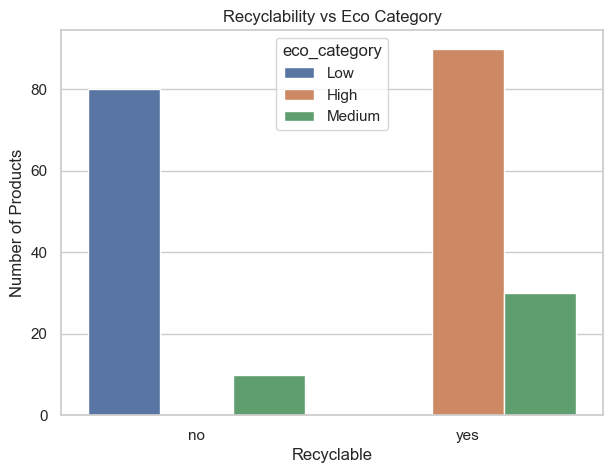


Insight:
Recyclable products generally show better sustainability performance.
This supports the idea that recyclability is an important feature for eco-friendly shopping.



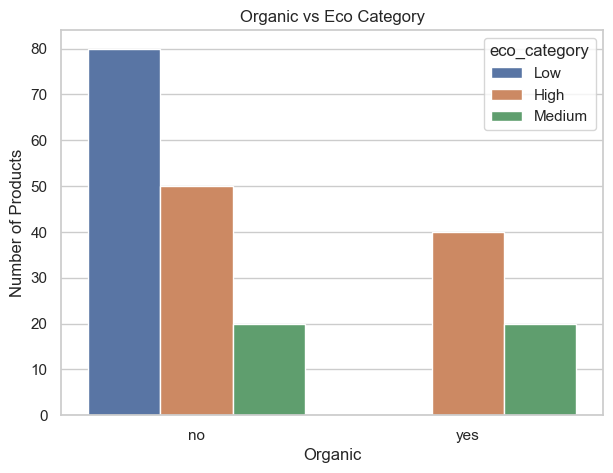


Insight:
Organic products are more likely to appear in higher eco categories,
showing that organic materials can improve product sustainability.



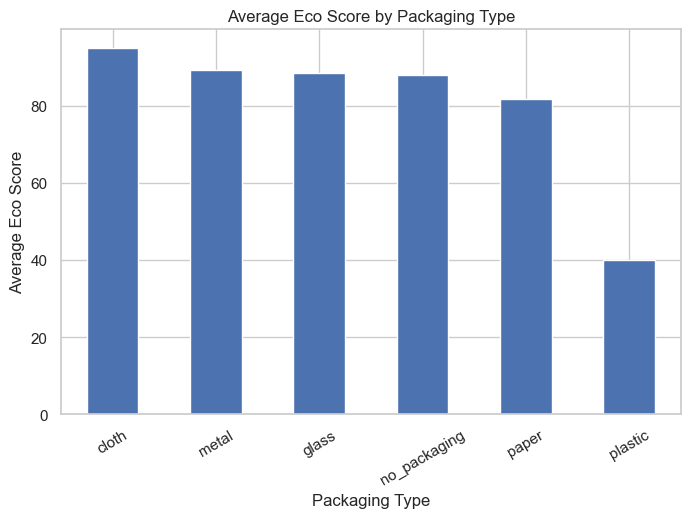


Insight:
Packaging materials with better recyclability and durability show higher average eco scores.
This proves packaging type is an important factor in sustainable shopping decisions.



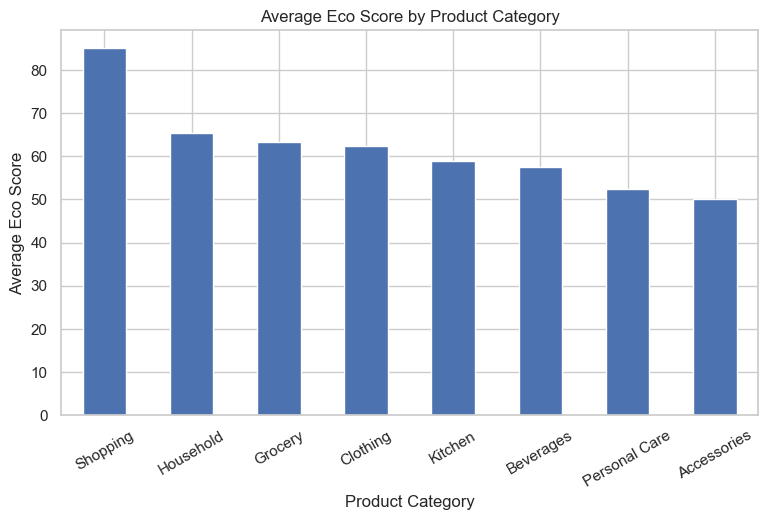


Insight:
This chart shows the average eco score of each product category.
It helps the chatbot and recommendation system suggest better categories to users.



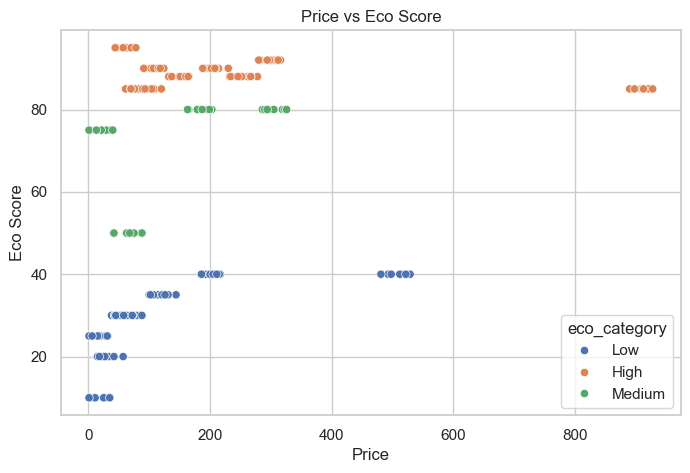


Insight:
This chart helps analyze whether higher sustainability always means higher price.
It is useful for recommending affordable eco-friendly options to users.


FINAL EDA CONCLUSION:

The EDA shows that packaging type, recyclability, organic status, durability,
and carbon impact are important factors affecting the eco category of a product.

Plastic and high carbon impact products generally have lower eco scores.
Reusable, recyclable, organic, and low carbon impact products usually receive higher eco scores.

These insights will be used in the ML model and chatbot logic of the
AI Eco-Friendly Shopping Assistant.

Target Classes:
['High' 'Low' 'Medium']
Model training completed successfully.
Model Accuracy: 0.9523809523809523

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        18
         Low       0.89      1.00      0.94        16
      Medium       1.00      0.75      0.86         8

    accuracy      

In [2]:
import pandas as pd
import random

# Load base dataset
df = pd.read_csv("C:\\Users\\CK\\Downloads\\Term-4\\AI\\Project\\AI_Eco_Friendly_Shopping_Assistant\\dataset\\eco_products.csv")

durability_levels = ["low", "medium", "high"]
carbon_levels = ["low", "medium", "high"]

expanded_data = []

# Expand dataset (~200 rows)
for _ in range(10):
    for _, row in df.iterrows():
        new_row = row.copy()

        new_row["price"] = max(1, row["price"] + random.randint(-20, 30))
        new_row["durability"] = random.choice(durability_levels)
        new_row["carbon_impact"] = random.choice(carbon_levels)

        expanded_data.append(new_row)

expanded_df = pd.DataFrame(expanded_data)

# Save new dataset
expanded_df.to_csv("C:\\Users\\CK\\Downloads\\Term-4\\AI\\Project\\AI_Eco_Friendly_Shopping_Assistant\\dataset\\eco_products_expanded.csv", index=False)

print("Dataset created:", expanded_df.shape)

# ============================================================
# AI ECO-FRIENDLY SHOPPING ASSISTANT
# STEP 3: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set chart style
sns.set(style="whitegrid")

# ------------------------------------------------------------
# 1. Load Expanded Dataset
# ------------------------------------------------------------

df = pd.read_csv("../dataset/eco_products_expanded.csv")

# Display first 5 rows
print("First 5 rows of the dataset:")
display(df.head())

# Display dataset shape
print("Dataset Shape:", df.shape)


# ------------------------------------------------------------
# 2. Basic Dataset Information
# ------------------------------------------------------------

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nEco Category Count:")
print(df["eco_category"].value_counts())


# ------------------------------------------------------------
# 3. Eco Category Distribution
# Purpose: To check how many products belong to Low, Medium,
# and High sustainability categories.
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))
sns.countplot(x="eco_category", data=df, order=["Low", "Medium", "High"])
plt.title("Eco Category Distribution")
plt.xlabel("Eco Category")
plt.ylabel("Number of Products")
plt.show()

print("""
Insight:
This chart shows the distribution of products across Low, Medium, and High eco categories.
It helps us understand whether the dataset is balanced for ML classification.
""")


# ------------------------------------------------------------
# 4. Packaging Type vs Eco Category
# Purpose: To analyze how packaging material affects product
# sustainability.
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))
sns.countplot(x="packaging_type", hue="eco_category", data=df)
plt.title("Packaging Type vs Eco Category")
plt.xlabel("Packaging Type")
plt.ylabel("Number of Products")
plt.xticks(rotation=30)
plt.show()

print("""
Insight:
Plastic packaging is generally linked with lower sustainability,
while recyclable packaging such as glass, metal, and paper tends to support better eco categories.
""")


# ------------------------------------------------------------
# 5. Eco Score Distribution
# Purpose: To understand how eco scores are spread across the dataset.
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
sns.histplot(df["eco_score"], bins=10, kde=True)
plt.title("Eco Score Distribution")
plt.xlabel("Eco Score")
plt.ylabel("Frequency")
plt.show()

print("""
Insight:
The eco score distribution shows how products vary in sustainability.
Higher scores represent more eco-friendly products, while lower scores indicate harmful or less sustainable products.
""")


# ------------------------------------------------------------
# 6. Category vs Eco Score
# Purpose: To compare average sustainability scores across product categories.
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
sns.boxplot(x="category", y="eco_score", data=df)
plt.title("Product Category vs Eco Score")
plt.xlabel("Product Category")
plt.ylabel("Eco Score")
plt.xticks(rotation=30)
plt.show()

print("""
Insight:
This chart helps identify which product categories generally perform better in sustainability.
Some categories may have both low and high eco scores depending on packaging, recyclability, and material type.
""")


# ------------------------------------------------------------
# 7. Carbon Impact vs Eco Category
# Purpose: To check relation between carbon impact and eco category.
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))
sns.countplot(x="carbon_impact", hue="eco_category", data=df)
plt.title("Carbon Impact vs Eco Category")
plt.xlabel("Carbon Impact")
plt.ylabel("Number of Products")
plt.show()

print("""
Insight:
Products with high carbon impact mostly fall into the Low eco category,
while low carbon impact products are more likely to be classified as High sustainability products.
""")


# ------------------------------------------------------------
# 8. Recyclable Products vs Eco Category
# Purpose: To see whether recyclable products have better sustainability.
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))
sns.countplot(x="recyclable", hue="eco_category", data=df)
plt.title("Recyclability vs Eco Category")
plt.xlabel("Recyclable")
plt.ylabel("Number of Products")
plt.show()

print("""
Insight:
Recyclable products generally show better sustainability performance.
This supports the idea that recyclability is an important feature for eco-friendly shopping.
""")


# ------------------------------------------------------------
# 9. Organic Products vs Eco Category
# Purpose: To compare organic and non-organic products.
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))
sns.countplot(x="organic", hue="eco_category", data=df)
plt.title("Organic vs Eco Category")
plt.xlabel("Organic")
plt.ylabel("Number of Products")
plt.show()

print("""
Insight:
Organic products are more likely to appear in higher eco categories,
showing that organic materials can improve product sustainability.
""")


# ------------------------------------------------------------
# 10. Average Eco Score by Packaging Type
# Purpose: To compare packaging materials based on average eco score.
# ------------------------------------------------------------

avg_packaging_score = df.groupby("packaging_type")["eco_score"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
avg_packaging_score.plot(kind="bar")
plt.title("Average Eco Score by Packaging Type")
plt.xlabel("Packaging Type")
plt.ylabel("Average Eco Score")
plt.xticks(rotation=30)
plt.show()

print("""
Insight:
Packaging materials with better recyclability and durability show higher average eco scores.
This proves packaging type is an important factor in sustainable shopping decisions.
""")


# ------------------------------------------------------------
# 11. Average Eco Score by Category
# Purpose: To identify which product categories are more sustainable.
# ------------------------------------------------------------

avg_category_score = df.groupby("category")["eco_score"].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
avg_category_score.plot(kind="bar")
plt.title("Average Eco Score by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Eco Score")
plt.xticks(rotation=30)
plt.show()

print("""
Insight:
This chart shows the average eco score of each product category.
It helps the chatbot and recommendation system suggest better categories to users.
""")


# ------------------------------------------------------------
# 12. Price vs Eco Score
# Purpose: To check whether eco-friendly products are always expensive.
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
sns.scatterplot(x="price", y="eco_score", hue="eco_category", data=df)
plt.title("Price vs Eco Score")
plt.xlabel("Price")
plt.ylabel("Eco Score")
plt.show()

print("""
Insight:
This chart helps analyze whether higher sustainability always means higher price.
It is useful for recommending affordable eco-friendly options to users.
""")


# ------------------------------------------------------------
# 13. Final EDA Conclusion
# ------------------------------------------------------------

print("""
FINAL EDA CONCLUSION:

The EDA shows that packaging type, recyclability, organic status, durability,
and carbon impact are important factors affecting the eco category of a product.

Plastic and high carbon impact products generally have lower eco scores.
Reusable, recyclable, organic, and low carbon impact products usually receive higher eco scores.

These insights will be used in the ML model and chatbot logic of the
AI Eco-Friendly Shopping Assistant.
""") 


Encoded X sample:


,category,price,packaging_type,recyclable,organic,durability,carbon_impact
0,1,19,5,0,0,0,0
1,1,194,2,1,0,0,0
2,7,36,4,1,0,2,0
3,7,62,0,1,0,0,0
4,6,33,5,0,0,0,1


Target classes:
['High' 'Low' 'Medium']
Model training completed successfully.
Model Accuracy: 0.9523809523809523

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        18
         Low       0.89      1.00      0.94        16
      Medium       1.00      0.75      0.86         8

    accuracy                           0.95        42
   macro avg       0.96      0.92      0.93        42
weighted avg       0.96      0.95      0.95        42


Confusion Matrix:
[[18  0  0]
 [ 0 16  0]
 [ 0  2  6]]
Model and encoders saved successfully in backend folder.


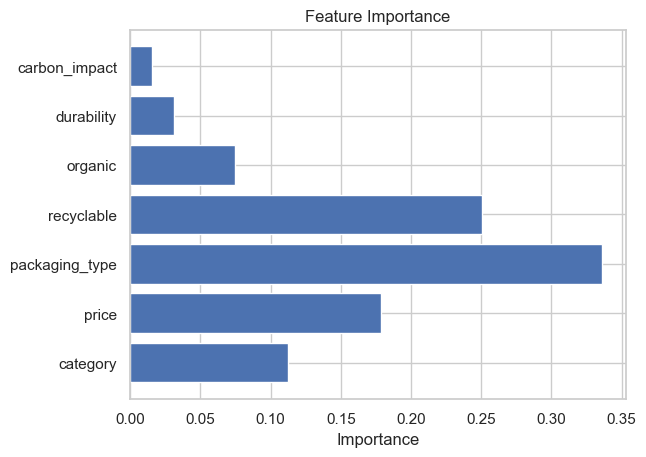

In [3]:
# ============================================================
# STEP 4: MACHINE LEARNING MODEL - CORRECTED VERSION
# Goal: Predict eco_category of a product
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import pandas as pd
import matplotlib.pyplot as plt
# ------------------------------------------------------------
# 1. Reload dataset fresh
# ------------------------------------------------------------

df = pd.read_csv("../dataset/eco_products_expanded.csv")

# ------------------------------------------------------------
# 2. Select Features and Target
# ------------------------------------------------------------

features = [
    "category",
    "price",
    "packaging_type",
    "recyclable",
    "organic",
    "durability",
    "carbon_impact"
]

target = "eco_category"

X = df[features].copy()
y = df[target].copy()

# ------------------------------------------------------------
# 3. Encode categorical feature columns
# ------------------------------------------------------------

label_encoders = {}

categorical_columns = [
    "category",
    "packaging_type",
    "recyclable",
    "organic",
    "durability",
    "carbon_impact"
]

for column in categorical_columns:
    le = LabelEncoder()
    X[column] = le.fit_transform(X[column])
    label_encoders[column] = le

# Encode target column
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

print("Encoded X sample:")
display(X.head())

print("Target classes:")
print(target_encoder.classes_)

# ------------------------------------------------------------
# 4. Train-test split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# ------------------------------------------------------------
# 5. Train Random Forest model
# ------------------------------------------------------------

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed successfully.")

# ------------------------------------------------------------
# 6. Prediction and Evaluation
# ------------------------------------------------------------

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=target_encoder.classes_
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ------------------------------------------------------------
# 7. Save model and encoders
# ------------------------------------------------------------

joblib.dump(model, "../backend/eco_model.pkl")
joblib.dump(label_encoders, "../backend/label_encoders.pkl")
joblib.dump(target_encoder, "../backend/target_encoder.pkl")

print("Model and encoders saved successfully in backend folder.")

importance = model.feature_importances_
feature_names = X.columns

plt.barh(feature_names, importance)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()